In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np


In [4]:
data  = pd.read_csv("Projects\Classification\Travel.csv")

In [5]:
data.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [6]:
data.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

<Axes: xlabel='Age', ylabel='Density'>

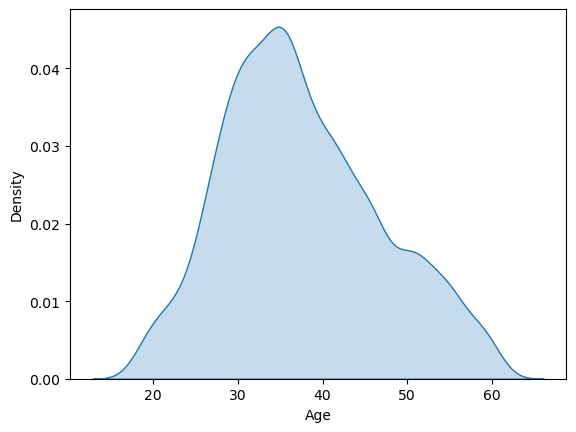

In [7]:
sns.kdeplot(data['Age'],fill=True,)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [9]:
data.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [10]:
cate = [] 
for i in data.columns:                 ## categorical features 
    if data[i].dtype == 'O':
        cate.append(i)
    

In [11]:
cate

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [12]:
for i in cate:
    print(data[i].value_counts())

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64
Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64


In [13]:
data['Gender'].replace("Fe Male","Female",inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\217519008.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].replace("Fe Male","Female",inplace=True)


In [14]:
data['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [15]:
data['MaritalStatus'].replace('Single','Unmarried',inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\780672499.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MaritalStatus'].replace('Single','Unmarried',inplace=True)


In [16]:
data['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [17]:
nul = [i for i in data.columns if data[i].isnull().any()]

In [18]:
len(nul)

8

In [19]:
nulcont = [i for i in nul if i not in cate]

In [20]:
nulcont

['Age',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [21]:
data['NumberOfTrips'].value_counts()

NumberOfTrips
2.0     1464
3.0     1079
1.0      620
4.0      478
5.0      458
6.0      322
7.0      218
8.0      105
19.0       1
21.0       1
20.0       1
22.0       1
Name: count, dtype: int64

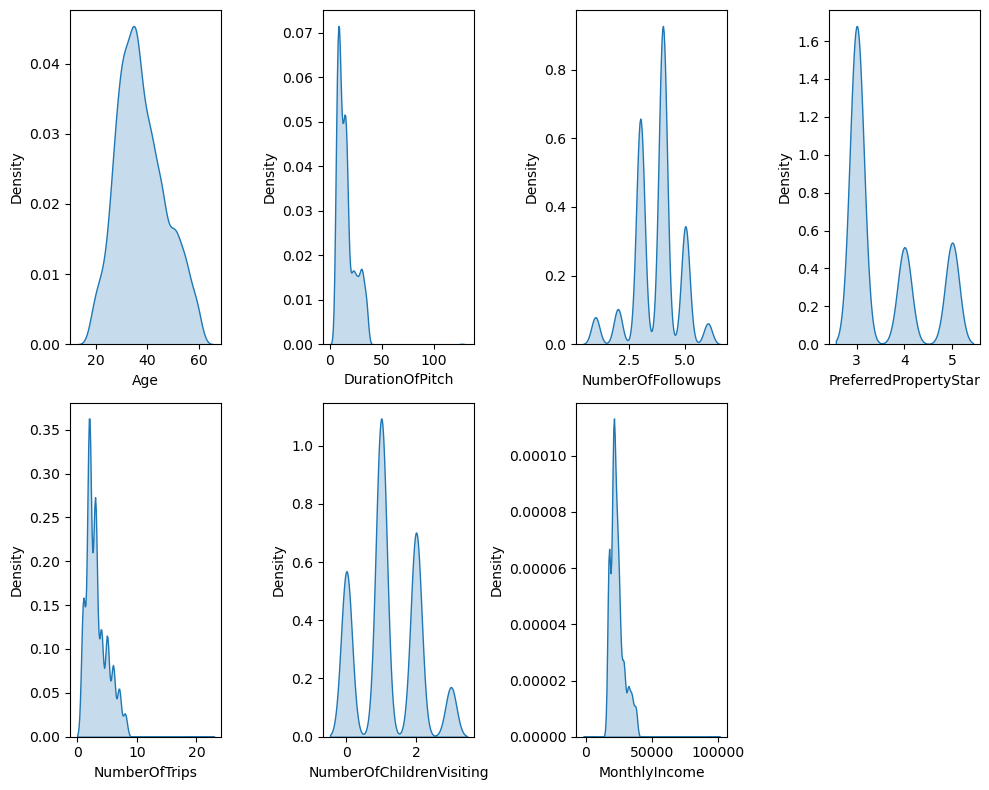

In [22]:
plt.figure(figsize=(10,8))
for i in range(0,len(nulcont)):
    plt.subplot(2,4,i+1)
    sns.kdeplot(data[nulcont[i]],fill=True,legend=True,)
    # plt.title(nulcont[i])
plt.tight_layout()

    


In [23]:
data

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Unmarried,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,5,0,2.0,Executive,20289.0


In [24]:
data.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [25]:
data['Age'] = pd.to_numeric(data['Age'])

In [26]:
data['Age'].fillna(data['Age'].median(),inplace=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\1102141790.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(),inplace=True)


In [27]:
data['DurationOfPitch'].fillna(data['DurationOfPitch'].median(),inplace=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\1953400877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DurationOfPitch'].fillna(data['DurationOfPitch'].median(),inplace=True)


In [28]:
data['NumberOfFollowups'].fillna(data['NumberOfFollowups'].mode()[0],inplace=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\3422349620.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['NumberOfFollowups'].fillna(data['NumberOfFollowups'].mode()[0],inplace=True)


In [29]:
data['NumberOfChildrenVisiting'].fillna(data['NumberOfChildrenVisiting'].mode()[0],inplace=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\3612902290.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['NumberOfChildrenVisiting'].fillna(data['NumberOfChildrenVisiting'].mode()[0],inplace=True)


In [30]:
data['PreferredPropertyStar'].fillna(data['PreferredPropertyStar'].mode()[0],inplace=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\1369377179.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['PreferredPropertyStar'].fillna(data['PreferredPropertyStar'].mode()[0],inplace=True)


In [31]:

data['NumberOfTrips'].fillna(data['NumberOfTrips'].mode()[0],inplace=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\2361288139.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['NumberOfTrips'].fillna(data['NumberOfTrips'].mode()[0],inplace=True)


In [32]:
data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(),inplace=True)



C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\957187740.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(),inplace=True)


In [33]:
data['TypeofContact'].fillna(data['TypeofContact'].mode()[0],inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\4050035622.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TypeofContact'].fillna(data['TypeofContact'].mode()[0],inplace=True)


In [34]:
data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17892\911915714.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MonthlyIncome'].fillna(data['MonthlyIncome'].median(),inplace=True)


In [35]:
data[data['TypeofContact'].isnull()]

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome


In [36]:
data.isnull().any()

CustomerID                  False
ProdTaken                   False
Age                         False
TypeofContact               False
CityTier                    False
DurationOfPitch             False
Occupation                  False
Gender                      False
NumberOfPersonVisiting      False
NumberOfFollowups           False
ProductPitched              False
PreferredPropertyStar       False
MaritalStatus               False
NumberOfTrips               False
Passport                    False
PitchSatisfactionScore      False
OwnCar                      False
NumberOfChildrenVisiting    False
Designation                 False
MonthlyIncome               False
dtype: bool

In [37]:
data.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [38]:
datanum = ['Age','CityTier','DurationOfPitch','NumberOfFollowups','PreferredPropertyStar','NumberOfTrips','MonthlyIncome','Passport', 'PitchSatisfactionScore', 'OwnCar','total_visits']

In [39]:
data['NumberOfPersonVisiting'].value_counts()

NumberOfPersonVisiting
3    2402
2    1418
4    1026
1      39
5       3
Name: count, dtype: int64

In [40]:
data['NumberOfChildrenVisiting'].value_counts()

NumberOfChildrenVisiting
1.0    2146
2.0    1335
0.0    1082
3.0     325
Name: count, dtype: int64

In [41]:
data[cate]

,TypeofContact,Occupation,Gender,ProductPitched,MaritalStatus,Designation
0,Self Enquiry,Salaried,Female,Deluxe,Unmarried,Manager
1,Company Invited,Salaried,Male,Deluxe,Divorced,Manager
2,Self Enquiry,Free Lancer,Male,Basic,Unmarried,Executive
3,Company Invited,Salaried,Female,Basic,Divorced,Executive
4,Self Enquiry,Small Business,Male,Basic,Divorced,Executive
...,...,...,...,...,...,...
4883,Self Enquiry,Small Business,Male,Deluxe,Unmarried,Manager
4884,Company Invited,Salaried,Male,Basic,Unmarried,Executive
4885,Self Enquiry,Salaried,Female,Standard,Married,Senior Manager
4886,Self Enquiry,Small Business,Male,Basic,Unmarried,Executive


In [42]:
data['total_visits'] = data['NumberOfChildrenVisiting'] + data['NumberOfPersonVisiting']
data.drop(columns=['NumberOfPersonVisiting','NumberOfChildrenVisiting'],axis=1,inplace=True)

In [43]:
data.drop(columns=['CustomerID'],axis=1,inplace=True)

In [44]:
x = data.drop('ProdTaken',axis=1)
y = data['ProdTaken']

In [45]:
x

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,total_visits
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,Manager,26576.0,4.0
4884,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Unmarried,3.0,1,3,1,Executive,21212.0,6.0
4885,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Unmarried,3.0,0,5,0,Executive,20289.0,5.0


In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=98)

In [48]:
x_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,total_visits
4787,37.0,Self Enquiry,1,13.0,Salaried,Male,6.0,Basic,3.0,Married,3.0,0,1,1,Executive,21419.0,4.0
416,38.0,Company Invited,1,8.0,Salaried,Male,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,16702.0,3.0
4880,59.0,Self Enquiry,1,28.0,Small Business,Female,4.0,Deluxe,4.0,Married,6.0,0,3,1,Manager,28686.0,6.0
982,38.0,Company Invited,1,13.0,Salaried,Male,1.0,Basic,3.0,Married,2.0,0,3,0,Executive,17610.0,2.0
2805,41.0,Self Enquiry,1,17.0,Salaried,Female,3.0,Basic,3.0,Divorced,5.0,1,3,0,Executive,20891.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2113,42.0,Self Enquiry,1,9.0,Salaried,Female,1.0,Deluxe,3.0,Married,3.0,1,5,1,Manager,20231.0,3.0
603,45.0,Self Enquiry,1,8.0,Salaried,Female,4.0,Basic,3.0,Unmarried,2.0,0,3,1,Executive,17274.0,4.0
3519,33.0,Self Enquiry,1,17.0,Small Business,Male,4.0,Standard,3.0,Unmarried,4.0,0,1,0,Senior Manager,29922.0,3.0
3252,30.0,Self Enquiry,1,35.0,Salaried,Female,4.0,Basic,3.0,Married,6.0,0,5,0,Executive,21192.0,6.0


In [49]:
x_train.shape

(3910, 17)

In [50]:
cate

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [51]:
datanum

['Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'MonthlyIncome',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'total_visits']

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder

numerictransformer = StandardScaler()
ord = OrdinalEncoder()

colu = ColumnTransformer([
    ("label encoder",ord,cate),
    ("numeric encoder",numerictransformer,datanum)
],

)

In [53]:
colu

ColumnTransformer(transformers=[('label encoder', OrdinalEncoder(),
                                 ['TypeofContact', 'Occupation', 'Gender',
                                  'ProductPitched', 'MaritalStatus',
                                  'Designation']),
                                ('numeric encoder', StandardScaler(),
                                 ['Age', 'CityTier', 'DurationOfPitch',
                                  'NumberOfFollowups', 'PreferredPropertyStar',
                                  'NumberOfTrips', 'MonthlyIncome', 'Passport',
                                  'PitchSatisfactionScore', 'OwnCar',
                                  'total_visits'])])

In [54]:
x_test.shape

(978, 17)

In [55]:
x_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,total_visits
4787,37.0,Self Enquiry,1,13.0,Salaried,Male,6.0,Basic,3.0,Married,3.0,0,1,1,Executive,21419.0,4.0
416,38.0,Company Invited,1,8.0,Salaried,Male,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,16702.0,3.0
4880,59.0,Self Enquiry,1,28.0,Small Business,Female,4.0,Deluxe,4.0,Married,6.0,0,3,1,Manager,28686.0,6.0
982,38.0,Company Invited,1,13.0,Salaried,Male,1.0,Basic,3.0,Married,2.0,0,3,0,Executive,17610.0,2.0
2805,41.0,Self Enquiry,1,17.0,Salaried,Female,3.0,Basic,3.0,Divorced,5.0,1,3,0,Executive,20891.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2113,42.0,Self Enquiry,1,9.0,Salaried,Female,1.0,Deluxe,3.0,Married,3.0,1,5,1,Manager,20231.0,3.0
603,45.0,Self Enquiry,1,8.0,Salaried,Female,4.0,Basic,3.0,Unmarried,2.0,0,3,1,Executive,17274.0,4.0
3519,33.0,Self Enquiry,1,17.0,Small Business,Male,4.0,Standard,3.0,Unmarried,4.0,0,1,0,Senior Manager,29922.0,3.0
3252,30.0,Self Enquiry,1,35.0,Salaried,Female,4.0,Basic,3.0,Married,6.0,0,5,0,Executive,21192.0,6.0


In [56]:
x_test

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,total_visits
1952,31.0,Self Enquiry,3,13.0,Small Business,Male,3.0,Deluxe,5.0,Married,3.0,0,1,0,Manager,22347.0,3.0
4073,35.0,Company Invited,3,9.0,Small Business,Female,4.0,Basic,3.0,Married,8.0,0,5,0,Executive,20909.0,5.0
1136,28.0,Self Enquiry,1,30.0,Small Business,Male,3.0,Basic,4.0,Married,2.0,1,1,0,Executive,17408.0,2.0
630,22.0,Self Enquiry,1,13.0,Salaried,Male,4.0,Deluxe,3.0,Divorced,7.0,0,2,1,Manager,19775.0,2.0
2124,39.0,Self Enquiry,2,8.0,Salaried,Female,4.0,Deluxe,3.0,Married,1.0,0,3,1,Manager,20204.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,46.0,Self Enquiry,1,8.0,Salaried,Male,3.0,Super Deluxe,3.0,Married,7.0,0,5,1,AVP,32861.0,2.0
2951,30.0,Self Enquiry,3,10.0,Small Business,Female,4.0,Deluxe,3.0,Divorced,3.0,0,2,0,Manager,24239.0,5.0
4151,53.0,Company Invited,3,9.0,Salaried,Male,5.0,King,3.0,Unmarried,2.0,1,1,1,VP,37746.0,5.0
2485,28.0,Self Enquiry,1,9.0,Salaried,Female,4.0,Basic,5.0,Married,3.0,0,3,0,Executive,21019.0,5.0


In [57]:
x_train = colu.fit_transform(x_train)

In [58]:
x_test = colu.transform(x_test)

In [59]:
x_test

array([[ 1.        ,  3.        ,  1.        , ..., -1.51716368,
        -1.27927618, -0.76898125],
       [ 0.        ,  3.        ,  0.        , ...,  1.4177083 ,
        -1.27927618,  0.64661041],
       [ 1.        ,  3.        ,  1.        , ..., -1.51716368,
        -1.27927618, -1.47677709],
       ...,
       [ 0.        ,  2.        ,  1.        , ..., -1.51716368,
         0.78169204,  0.64661041],
       [ 1.        ,  2.        ,  0.        , ..., -0.04972769,
        -1.27927618,  0.64661041],
       [ 0.        ,  3.        ,  1.        , ..., -0.04972769,
         0.78169204, -0.76898125]])

In [60]:
x_train

array([[ 1.        ,  2.        ,  1.        , ..., -1.51716368,
         0.78169204, -0.06118542],
       [ 0.        ,  2.        ,  1.        , ...,  1.4177083 ,
         0.78169204, -0.76898125],
       [ 1.        ,  3.        ,  0.        , ..., -0.04972769,
         0.78169204,  1.35440625],
       ...,
       [ 1.        ,  3.        ,  1.        , ..., -1.51716368,
        -1.27927618, -0.76898125],
       [ 1.        ,  2.        ,  0.        , ...,  1.4177083 ,
        -1.27927618,  1.35440625],
       [ 1.        ,  3.        ,  0.        , ..., -0.04972769,
         0.78169204, -1.47677709]])

In [61]:
x.isnull().any()

Age                       False
TypeofContact             False
CityTier                  False
DurationOfPitch           False
Occupation                False
Gender                    False
NumberOfFollowups         False
ProductPitched            False
PreferredPropertyStar     False
MaritalStatus             False
NumberOfTrips             False
Passport                  False
PitchSatisfactionScore    False
OwnCar                    False
Designation               False
MonthlyIncome             False
total_visits              False
dtype: bool

In [62]:
x_t = pd.DataFrame(x_train)
print(x_t)

       0    1    2    3    4   ...        12        13        14        15        16
0     1.0  2.0  1.0  0.0  1.0  ... -0.414952 -0.638347 -1.517164  0.781692 -0.061185
1     0.0  2.0  1.0  0.0  0.0  ... -1.325143  1.566545  1.417708  0.781692 -0.768981
2     1.0  3.0  0.0  1.0  1.0  ...  0.987286 -0.638347 -0.049728  0.781692  1.354406
3     0.0  2.0  1.0  0.0  1.0  ... -1.149935 -0.638347 -0.049728 -1.279276 -1.476777
4     1.0  2.0  0.0  0.0  0.0  ... -0.516835  1.566545 -0.049728 -1.279276  0.646610
...   ...  ...  ...  ...  ...  ...       ...       ...       ...       ...       ...
3905  1.0  2.0  0.0  1.0  1.0  ... -0.644188  1.566545  1.417708  0.781692 -0.768981
3906  1.0  2.0  0.0  0.0  2.0  ... -1.214770 -0.638347 -0.049728  0.781692 -0.061185
3907  1.0  3.0  1.0  3.0  2.0  ...  1.225784 -0.638347 -1.517164 -1.279276 -0.768981
3908  1.0  2.0  0.0  0.0  1.0  ... -0.458754 -0.638347  1.417708 -1.279276  1.354406
3909  1.0  3.0  0.0  1.0  2.0  ... -0.339312 -0.638347 -0.049728 

In [63]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 


#### Adaboost implementation is also done here

In [64]:
models = {
    "gc" : RandomForestClassifier(),
    "DT" : DecisionTreeClassifier(),
    "adaboost" : AdaBoostClassifier(n_estimators=50),                ## by hyperparameter tuning
    "gradboost" : GradientBoostingClassifier(n_estimators = 80, loss ='log_loss', learning_rate = 0.3), 
    "xgboost" : XGBClassifier()    
}

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(x_train,y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # train performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) 
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred) 
    model_train_recall = recall_score(y_train, y_train_pred) 
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)

    # test performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) 
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') 
    model_test_precision = precision_score(y_test, y_test_pred) 
    model_test_recall = recall_score(y_test, y_test_pred) 
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)

    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    

gc
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9387
- F1 score: 0.9364
- Precision: 0.9193
- Recall: 0.7590
- Roc Auc Score: 0.8712
DT
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8967
- F1 score: 0.8968
- Precision: 0.7398
- Recall: 0.7436
- Roc Auc Score: 0.8392
adaboost
Model performance for Training set
- Accuracy: 0.8491
- F1 score: 0.8177
- Precision: 0.7689
- Recall: 0.2662
- Roc Auc Score: 0.6240
----------------------------------
Model performance for Test set
- Accuracy: 0.8354
- F1 score: 0.7965
- Precision: 0.8036
- Recall: 0.2308
- Roc Auc Score: 0.6084
gradboost
Model performance for Training set
- Accuracy: 0.9263
- F1 score: 0.9210
- Pre

### Hyperparameter Tuning

In [65]:
from sklearn.model_selection import RandomizedSearchCV

In [66]:
para = {"n_estimators" : [50,60,70,80,90]}
grad_para = { "loss" : ['log_loss', 'exponential'], 'learning_rate' : [0.1,0.05,0.3,0.01],
             "n_estimators" : [50,60,80,90,100]}


In [67]:
cv_models = [("adda",AdaBoostClassifier(),para),
             ("gradboost", GradientBoostingClassifier(),grad_para)]

In [68]:
x_test

array([[ 1.        ,  3.        ,  1.        , ..., -1.51716368,
        -1.27927618, -0.76898125],
       [ 0.        ,  3.        ,  0.        , ...,  1.4177083 ,
        -1.27927618,  0.64661041],
       [ 1.        ,  3.        ,  1.        , ..., -1.51716368,
        -1.27927618, -1.47677709],
       ...,
       [ 0.        ,  2.        ,  1.        , ..., -1.51716368,
         0.78169204,  0.64661041],
       [ 1.        ,  2.        ,  0.        , ..., -0.04972769,
        -1.27927618,  0.64661041],
       [ 0.        ,  3.        ,  1.        , ..., -0.04972769,
         0.78169204, -0.76898125]])

In [70]:
model_p = {}
for name,model,param in cv_models:
    gc = RandomizedSearchCV(estimator=model,param_distributions=param,n_jobs=-1,
                                verbose=2,cv=3,n_iter=100,random_state=89)
    gc.fit(x_train,y_train)
    model_p[name] = gc.best_params_

for i in model_p:
    print(f"Best params for {i} -------")
    print(model_p[i])



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=100. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=100. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params for adda -------
{'n_estimators': 50}
Best params for gradboost -------
{'n_estimators': 100, 'loss': 'log_loss', 'learning_rate': 0.3}


In [71]:
print(type(model_p))

<class 'dict'>
